# 07. Regression Models

**Aim:** Implement and evaluate linear and logistic regression on image features.

## Theory

Linear regression models the relationship between numeric predictors and a continuous target, while logistic regression predicts class probabilities for classification tasks. For regression, common evaluation metrics include R-squared, MSE, and MAE. For classification, accuracy, precision, recall, F1-score, and confusion matrices help measure prediction quality.

In [1]:
import os
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image, ImageFile
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    silhouette_score,
)

ImageFile.LOAD_TRUNCATED_IMAGES = True
warnings.filterwarnings('ignore')
os.environ.setdefault('MPLCONFIGDIR', os.path.abspath('../logs/.mplconfig'))
os.makedirs(os.environ['MPLCONFIGDIR'], exist_ok=True)
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

TRAIN_DIR = Path('../data/PlantDoc-Dataset-master/train/')
TEST_DIR = Path('../data/PlantDoc-Dataset-master/test/')
MANIFEST_PATH = Path('../data/dataset_manifest.csv')
CLEAN_MANIFEST_PATH = Path('../data/dataset_manifest_clean.csv')
FEATURES_PATH = Path('../data/image_features.csv')

def scan_split(split_dir: Path, split_name: str) -> pd.DataFrame:
    records = []
    if not split_dir.exists():
        return pd.DataFrame(columns=['image_path', 'class_name', 'split'])
    for class_dir in sorted([p for p in split_dir.iterdir() if p.is_dir()]):
        for image_path in sorted(class_dir.rglob('*')):
            if image_path.is_file():
                records.append({
                    'image_path': str(image_path.as_posix()),
                    'class_name': class_dir.name,
                    'split': split_name,
                })
    return pd.DataFrame(records)


def ensure_manifest(prefer_clean: bool = True) -> pd.DataFrame:
    target = CLEAN_MANIFEST_PATH if prefer_clean and CLEAN_MANIFEST_PATH.exists() else MANIFEST_PATH
    if target.exists():
        return pd.read_csv(target)

    train_df = scan_split(TRAIN_DIR, 'train')
    test_df = scan_split(TEST_DIR, 'test')
    full_df = pd.concat([train_df, test_df], ignore_index=True)
    full_df['class_name'] = full_df['class_name'].astype(str).str.strip()
    full_df = full_df.drop_duplicates(subset=['image_path']).reset_index(drop=True)
    return full_df


def validate_image(image_path: str):
    path = Path(image_path)
    if not path.exists():
        return False, 'missing'
    try:
        with Image.open(path) as img:
            img.verify()
        return True, 'ok'
    except Exception:
        return False, 'corrupt'


def load_rgb_image(image_path: str, size=(224, 224)):
    with Image.open(image_path) as img:
        rgb = img.convert('RGB').resize(size)
        return np.array(rgb)


def extract_rgb_features(image_array: np.ndarray) -> dict:
    channels = image_array.reshape(-1, 3)
    return {
        'mean_r': float(channels[:, 0].mean()),
        'mean_g': float(channels[:, 1].mean()),
        'mean_b': float(channels[:, 2].mean()),
        'std_r': float(channels[:, 0].std()),
        'std_g': float(channels[:, 1].std()),
        'std_b': float(channels[:, 2].std()),
    }


def ensure_features() -> pd.DataFrame:
    if FEATURES_PATH.exists():
        return pd.read_csv(FEATURES_PATH)

    manifest_df = ensure_manifest(prefer_clean=True).copy()
    quality_records = []
    for image_path in manifest_df['image_path']:
        valid, status = validate_image(image_path)
        quality_records.append((valid, status))
    manifest_df[['is_valid_image', 'file_status']] = pd.DataFrame(quality_records, index=manifest_df.index)
    manifest_df = manifest_df[manifest_df['is_valid_image']].copy().reset_index(drop=True)

    feature_rows = []
    for row in manifest_df.itertuples(index=False):
        image_array = load_rgb_image(row.image_path)
        feature_rows.append({
            'image_path': row.image_path,
            'class_name': row.class_name,
            'split': row.split,
            **extract_rgb_features(image_array),
        })

    features_df = pd.DataFrame(feature_rows)
    return features_df

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay

## Code

,metric,value
0,R2,0.751600
1,MSE,483.970211
2,MAE,16.950428


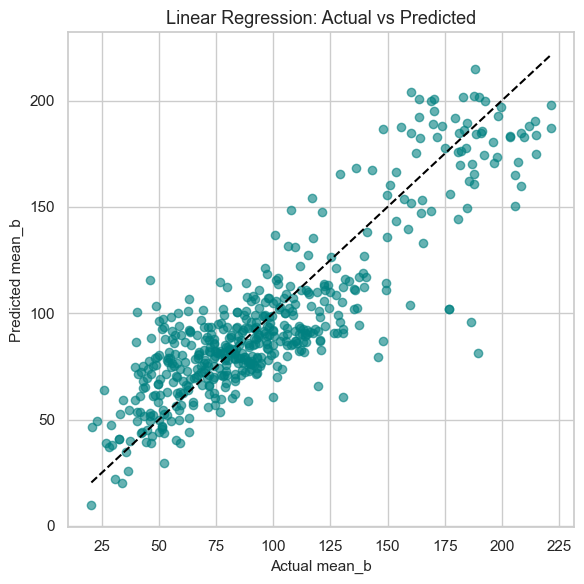

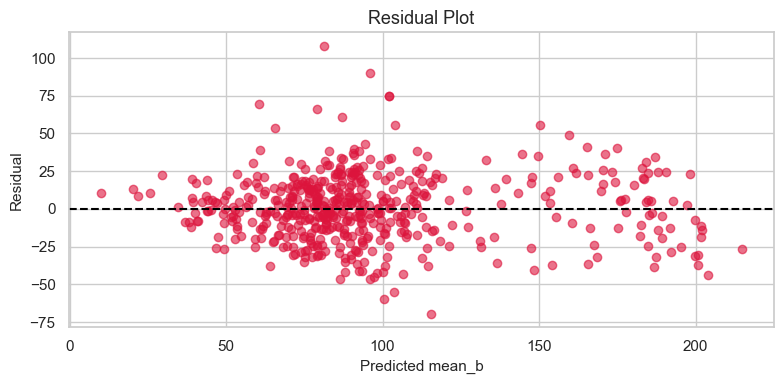

Logistic regression accuracy: 0.3873239436619718

Classification report:
                            precision    recall  f1-score   support

          Corn leaf blight       0.37      0.64      0.47        39
            Corn rust leaf       0.40      0.17      0.24        23
            Raspberry leaf       0.45      0.62      0.53        24
Squash Powdery mildew leaf       0.29      0.08      0.12        26
 Tomato Septoria leaf spot       0.36      0.30      0.33        30

                  accuracy                           0.39       142
                 macro avg       0.37      0.36      0.34       142
              weighted avg       0.37      0.39      0.35       142



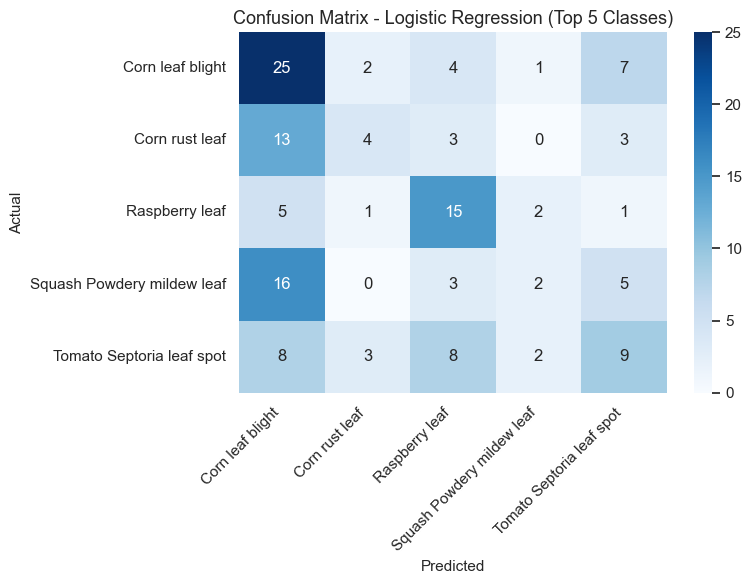

In [2]:
features_df = ensure_features().copy()
feature_cols = ['mean_r', 'mean_g', 'std_r', 'std_g', 'std_b']
X_reg = features_df[feature_cols]
y_reg = features_df['mean_b']

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)
linear_model = LinearRegression()
linear_model.fit(X_train_reg, y_train_reg)
y_pred_reg = linear_model.predict(X_test_reg)

reg_metrics = pd.DataFrame({
    'metric': ['R2', 'MSE', 'MAE'],
    'value': [
        r2_score(y_test_reg, y_pred_reg),
        mean_squared_error(y_test_reg, y_pred_reg),
        mean_absolute_error(y_test_reg, y_pred_reg),
    ]
})
display(reg_metrics)

plt.figure(figsize=(6, 6))
plt.scatter(y_test_reg, y_pred_reg, alpha=0.6, color='teal')
plt.plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], color='black', linestyle='--')
plt.xlabel('Actual mean_b')
plt.ylabel('Predicted mean_b')
plt.title('Linear Regression: Actual vs Predicted')
plt.tight_layout()
plt.show()

residuals = y_test_reg - y_pred_reg
plt.figure(figsize=(8, 4))
plt.scatter(y_pred_reg, residuals, alpha=0.6, color='crimson')
plt.axhline(0, color='black', linestyle='--')
plt.xlabel('Predicted mean_b')
plt.ylabel('Residual')
plt.title('Residual Plot')
plt.tight_layout()
plt.show()

top_5_classes = features_df['class_name'].value_counts().head(5).index
log_df = features_df[features_df['class_name'].isin(top_5_classes)].copy()
X_cls = log_df[['mean_r', 'mean_g', 'mean_b', 'std_r', 'std_g', 'std_b']]
label_encoder = LabelEncoder()
y_cls = label_encoder.fit_transform(log_df['class_name'])

X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_cls, y_cls, test_size=0.2, random_state=42, stratify=y_cls
)
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_cls, y_train_cls)
y_pred_cls = log_model.predict(X_test_cls)

print('Logistic regression accuracy:', accuracy_score(y_test_cls, y_pred_cls))
print('\nClassification report:')
print(classification_report(y_test_cls, y_pred_cls, target_names=label_encoder.classes_))

cm = confusion_matrix(y_test_cls, y_pred_cls)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix - Logistic Regression (Top 5 Classes)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## Results & Evaluation

In [3]:
print('Linear regression metrics:')
display(reg_metrics)
print('\nTop 5 classes used for logistic regression:')
print(top_5_classes.tolist())

Linear regression metrics:


,metric,value
0,R2,0.751600
1,MSE,483.970211
2,MAE,16.950428



Top 5 classes used for logistic regression:
['Corn leaf blight', 'Tomato Septoria leaf spot', 'Squash Powdery mildew leaf', 'Raspberry leaf', 'Corn rust leaf']


## Conclusion

The regression notebook demonstrates both continuous prediction and multi-class classification using compact RGB features. It shows how the same feature table can support different supervised learning tasks depending on the target variable chosen.